# MDI3003 – Lab 04: Probabilistic Customer Segmentation (Naive Bayes)
**Dataset A**: Customer Segmentation (JanataHack, Analytics Vidhya / Kaggle mirror `vetrirah/customer`)

Student Name: _____________Harshita_________________


In [1]:
from pathlib import Path
import json, platform, sys, time, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from joblib import dump, load

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, KBinsDiscretizer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB, BernoulliNB
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score)

SEED = 42
np.random.seed(SEED)
REG_NO = "23MID0043"  # <-- replace with your actual registration number

OUT = Path('lab04_outputs')
for d in ['figures', 'models', 'artifacts', 'results']:
    (OUT / d).mkdir(parents=True, exist_ok=True)

versions = {
    'python': sys.version, 'platform': platform.platform(),
    'pandas': pd.__version__, 'numpy': np.__version__,
    'scikit_learn': sklearn.__version__, 'random_seed': SEED,
}
(OUT / 'artifacts' / 'versions.json').write_text(json.dumps(versions, indent=2))
print(versions)

{'python': '3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]', 'platform': 'Linux-6.18.44-fc-v21-x86_64-with-glibc2.39', 'pandas': '3.0.2', 'numpy': '2.4.4', 'scikit_learn': '1.8.0', 'random_seed': 42}


## A2. Load and validate the dataset (Fixed Dataset Pack)
The instructor-issued (or verified public mirror) dataset pack for **Dataset A** must be placed at `DATA_PATH`.
Verified sources:
- https://www.analyticsvidhya.com/datahack/contest/janatahack-customer-segmentation
- https://www.kaggle.com/datasets/vetrirah/customer

In [2]:
DATA_PATH = Path('Train_aBjfeNk.csv')  # MODIFY to your dataset-pack path
TARGET = 'Segmentation'
ID_COL = 'ID'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
required = {TARGET, ID_COL}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
if df[TARGET].nunique() < 2:
    raise ValueError('Target must contain at least two classes.')

dataset_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('Dataset SHA-256:', dataset_hash)
print(df.shape)
display(df.head())
print(df[TARGET].value_counts(dropna=False).sort_index())

Dataset SHA-256: 4245166ea666055eaeb151aecf2d16c346cdb230749eb064949684c965bf7355
(8068, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


Segmentation
A    1972
B    1858
C    1970
D    2268
Name: count, dtype: int64


### 7.5 / 7.6 Label-provenance, circularity, and psychographic-measurement audit
- **Label definition**: `Segmentation` (A–D) is a business-assigned segment supplied by the competition organiser;
  the exact construction rule is not publicly disclosed.
- **Circularity check**: no predictor is a deterministic transform of the label and no timestamps exist that would
  allow post-label leakage.
- **`Var_1`** (anonymised category `Cat_1`–`Cat_7`): provenance is **unknown** — treated as psychographic with caution,
  never as ground truth.
- **`Spending_Score`** (Low/Average/High): most plausibly a behaviourally-derived indicator; exact derivation is
  undocumented.
- **Caveat**: used here as a pedagogical leakage-safe classification exercise, not a validated deployment case.

## A3. Feature groups (mapped onto Dataset A's actual schema)

In [3]:
DEMOGRAPHIC = ['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Family_Size', 'Work_Experience']
PSYCHOGRAPHIC = ['Var_1']
BEHAVIORAL = ['Spending_Score']

def existing(cols):
    return [c for c in cols if c in df.columns]

DEMOGRAPHIC, PSYCHOGRAPHIC, BEHAVIORAL = map(existing, [DEMOGRAPHIC, PSYCHOGRAPHIC, BEHAVIORAL])
ALL_FEATURES = list(dict.fromkeys(DEMOGRAPHIC + PSYCHOGRAPHIC + BEHAVIORAL))
assert ID_COL not in ALL_FEATURES

feature_manifest = {'demographic': DEMOGRAPHIC, 'psychographic': PSYCHOGRAPHIC,
                     'behavioral': BEHAVIORAL, 'all_features': ALL_FEATURES}
(OUT / 'artifacts' / 'feature_manifest.json').write_text(json.dumps(feature_manifest, indent=2))
print(json.dumps(feature_manifest, indent=2))

{
  "demographic": [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size",
    "Work_Experience"
  ],
  "psychographic": [
    "Var_1"
  ],
  "behavioral": [
    "Spending_Score"
  ],
  "all_features": [
    "Gender",
    "Ever_Married",
    "Age",
    "Graduated",
    "Profession",
    "Family_Size",
    "Work_Experience",
    "Var_1",
    "Spending_Score"
  ]
}


## A4. Data-quality and class-distribution audit

,dtype,missing_count,missing_percent,unique_count
Gender,str,0,0.00,2
Ever_Married,str,140,1.74,3
Age,int64,0,0.00,67
Graduated,str,78,0.97,3
Profession,str,124,1.54,10
Family_Size,float64,335,4.15,10
Work_Experience,float64,829,10.28,16
Var_1,str,76,0.94,8
Spending_Score,str,0,0.00,3
Segmentation,str,0,0.00,4


Exact duplicate rows: 0
Duplicate feature profiles: 734


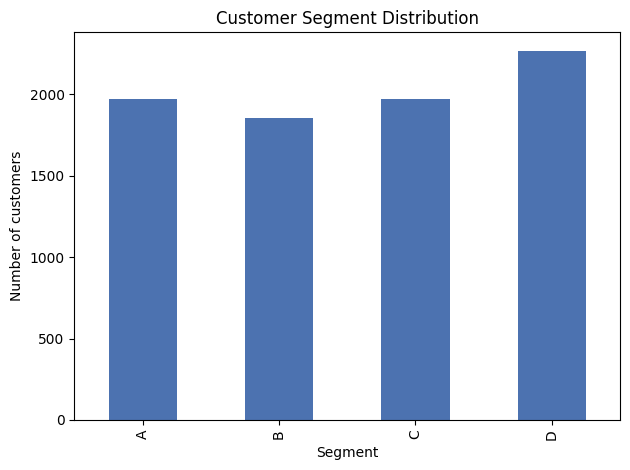

In [4]:
summary = pd.DataFrame({
    'dtype': df[ALL_FEATURES + [TARGET]].dtypes.astype(str),
    'missing_count': df[ALL_FEATURES + [TARGET]].isna().sum(),
    'missing_percent': (100 * df[ALL_FEATURES + [TARGET]].isna().mean()).round(2),
    'unique_count': df[ALL_FEATURES + [TARGET]].nunique(dropna=False),
})
summary.to_csv(OUT / 'results' / 'data_audit.csv')
display(summary)

print('Exact duplicate rows:', df.duplicated().sum())
print('Duplicate feature profiles:', df.duplicated(subset=ALL_FEATURES).sum())

class_counts = df[TARGET].value_counts().sort_index()
ax = class_counts.plot(kind='bar', title='Customer Segment Distribution', color='#4C72B0')
ax.set_xlabel('Segment'); ax.set_ylabel('Number of customers')
plt.tight_layout(); plt.savefig(OUT / 'figures' / 'class_distribution.png', dpi=150); plt.show()

## A5. Create and save the locked stratified split (80/20)

In [5]:
usable = df.dropna(subset=[TARGET]).copy()
train_df, test_df = train_test_split(usable, test_size=0.20, random_state=SEED, stratify=usable[TARGET])
assert set(train_df[ID_COL]).isdisjoint(set(test_df[ID_COL]))

split_manifest = pd.concat([
    train_df[[ID_COL]].assign(split='train'),
    test_df[[ID_COL]].assign(split='test'),
], ignore_index=True)
split_manifest.to_csv(OUT / 'artifacts' / 'split_manifest.csv', index=False)

X_train, y_train = train_df[ALL_FEATURES], train_df[TARGET]
X_test, y_test = test_df[ALL_FEATURES], test_df[TARGET]
print(X_train.shape, X_test.shape)

(6454, 9) (1614, 9)


## A6. Verify numerical, categorical, and binary feature lists

In [6]:
numeric_cols = [c for c in ALL_FEATURES if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in ALL_FEATURES if c not in numeric_cols]
binary_cols = [c for c in categorical_cols
               if set(df[c].dropna().astype(str).unique()).issubset({'0','1','False','True','No','Yes'})]
nominal_cols = [c for c in categorical_cols if c not in binary_cols]
print('Numeric:', numeric_cols)
print('Nominal:', nominal_cols)
print('Binary:', binary_cols)

Numeric: ['Age', 'Family_Size', 'Work_Experience']
Nominal: ['Gender', 'Profession', 'Var_1', 'Spending_Score']
Binary: ['Ever_Married', 'Graduated']


## A7. Build leakage-safe common pipelines
`SafeOrdinalToNonNegative` maps known categories to `1..K` and reserves `0` for unseen categories, guaranteeing
non-negative integer codes for `CategoricalNB`. Note the `check_is_fitted(self, "enc_")` guard and the trailing-underscore
`enc_` attribute set only inside `fit` — required for scikit-learn's fitted-state detection to work correctly when this
transformer is nested inside a `ColumnTransformer` inside a `Pipeline`.

In [7]:
class SafeOrdinalToNonNegative(BaseEstimator, TransformerMixin):
    """Encode known categories as 1..K; unseen categories map to 0."""
    def fit(self, X, y=None):
        self.enc_ = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.enc_.fit(X)
        return self
    def transform(self, X):
        check_is_fitted(self, 'enc_')
        return self.enc_.transform(X).astype(int) + 1

numeric_binary = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('bins', KBinsDiscretizer(n_bins=5, encode='onehot', strategy='quantile')),
])
category_ohe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
bernoulli_preprocessor = ColumnTransformer([
    ('num_bins', numeric_binary, numeric_cols),
    ('cat', category_ohe, nominal_cols + binary_cols),
], remainder='drop')

cat_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('bins', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')),
])
cat_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('safe_ordinal', SafeOrdinalToNonNegative()),
])
categorical_nb_preprocessor = ColumnTransformer([
    ('num', cat_num, numeric_cols),
    ('cat', cat_cat, nominal_cols + binary_cols),
], remainder='drop')

core_pipelines = {
    'Dummy_most_frequent': Pipeline([('prep', bernoulli_preprocessor), ('model', DummyClassifier(strategy='most_frequent'))]),
    'BernoulliNB': Pipeline([('prep', bernoulli_preprocessor), ('model', BernoulliNB(alpha=1.0, binarize=0.0))]),
    'CategoricalNB_mixed': Pipeline([('prep', categorical_nb_preprocessor), ('model', CategoricalNB(alpha=1.0))]),
}
if numeric_cols:
    gaussian_preprocessor = ColumnTransformer([('num', SimpleImputer(strategy='median'), numeric_cols)], remainder='drop')
    core_pipelines['GaussianNB_numeric_only'] = Pipeline([('prep', gaussian_preprocessor), ('model', GaussianNB(var_smoothing=1e-9))])

# Verify CategoricalNB non-negativity constraint using TRAINING data only
Xt_cat = categorical_nb_preprocessor.fit_transform(X_train)
assert np.nanmin(np.asarray(Xt_cat)) >= 0, 'CategoricalNB received a negative category code.'
print('Core models:', list(core_pipelines.keys()))

Core models: ['Dummy_most_frequent', 'BernoulliNB', 'CategoricalNB_mixed', 'GaussianNB_numeric_only']


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


## A8–A9. Baseline and cross-validated core models (identical folds)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior,

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior,

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior,

,model,accuracy_mean,macro_f1_mean,macro_f1_sd,weighted_f1_mean,cv_time_seconds
0,CategoricalNB_mixed,0.509450,0.484523,0.010115,0.493837,0.206287
1,BernoulliNB,0.503099,0.480073,0.008721,0.489105,0.213394
2,GaussianNB_numeric_only,0.420205,0.371894,0.011872,0.382897,0.102839
3,Dummy_most_frequent,0.281066,0.109700,0.000076,0.123332,0.179165


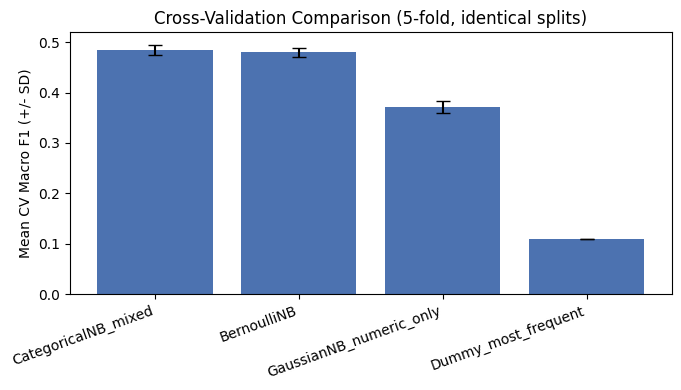

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'accuracy': 'accuracy', 'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}

rows, fold_rows = [], []
for name, pipe in core_pipelines.items():
    start = time.perf_counter()
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    elapsed = time.perf_counter() - start
    rows.append({'model': name, 'accuracy_mean': scores['test_accuracy'].mean(),
                 'macro_f1_mean': scores['test_macro_f1'].mean(),
                 'macro_f1_sd': scores['test_macro_f1'].std(ddof=1),
                 'weighted_f1_mean': scores['test_weighted_f1'].mean(),
                 'cv_time_seconds': elapsed})
    for fold_i, v in enumerate(scores['test_macro_f1'], start=1):
        fold_rows.append({'model': name, 'fold': fold_i, 'macro_f1': v})

cv_results = pd.DataFrame(rows).sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)
cv_results.to_csv(OUT / 'results' / f'{REG_NO}_Lab04_CV_Results.csv', index=False)
pd.DataFrame(fold_rows).to_csv(OUT / 'results' / 'cv_fold_level_macro_f1.csv', index=False)
display(cv_results)

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(cv_results['model'], cv_results['macro_f1_mean'], yerr=cv_results['macro_f1_sd'], capsize=5, color='#4C72B0')
ax.set_ylabel('Mean CV Macro F1 (+/- SD)'); ax.set_title('Cross-Validation Comparison (5-fold, identical splits)')
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(OUT / 'figures' / 'cv_comparison.png', dpi=150); plt.show()

### Core uncertainty rule
Report the fold-level macro-F1 values, their mean, and SD; do **not** interpret a small mean difference as decisive
when fold variability overlaps between the top two models.

## Feature-group ablation (one predeclared core model, identical folds)

Declared core model for ablation: CategoricalNB_mixed


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior,

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior,

,declared_core_model,feature_group,n_features,macro_f1_mean,macro_f1_sd,weighted_f1_mean
0,CategoricalNB_mixed,Demographic,7,0.485133,0.012111,0.494016
1,CategoricalNB_mixed,Psychographic,1,0.199714,0.011239,0.209143
2,CategoricalNB_mixed,Behavioral,1,0.265309,0.008388,0.279515
3,CategoricalNB_mixed,Combined,9,0.484523,0.010115,0.493837


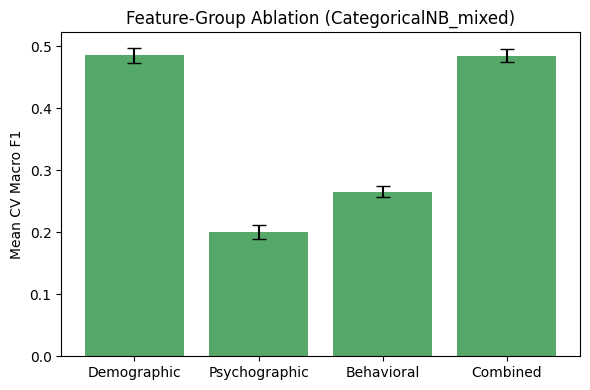

In [9]:
non_dummy = cv_results[cv_results['model'] != 'Dummy_most_frequent']
DECLARED_CORE_MODEL = non_dummy.iloc[0]['model']
print('Declared core model for ablation:', DECLARED_CORE_MODEL)

def build_pipeline_for(model_name, columns):
    num_c = [c for c in columns if c in numeric_cols]
    nom_c = [c for c in columns if c in nominal_cols]
    bin_c = [c for c in columns if c in binary_cols]
    if model_name == 'BernoulliNB':
        prep = ColumnTransformer([
            ('num_bins', Pipeline([('imputer', SimpleImputer(strategy='median')),
                                    ('bins', KBinsDiscretizer(n_bins=5, encode='onehot', strategy='quantile'))]), num_c),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                               ('onehot', OneHotEncoder(handle_unknown='ignore'))]), nom_c + bin_c),
        ], remainder='drop')
        return Pipeline([('prep', prep), ('model', BernoulliNB(alpha=1.0, binarize=0.0))])
    elif model_name == 'CategoricalNB_mixed':
        prep = ColumnTransformer([
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                               ('bins', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'))]), num_c),
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                               ('safe_ordinal', SafeOrdinalToNonNegative())]), nom_c + bin_c),
        ], remainder='drop')
        return Pipeline([('prep', prep), ('model', CategoricalNB(alpha=1.0))])
    elif model_name == 'GaussianNB_numeric_only':
        prep = ColumnTransformer([('num', SimpleImputer(strategy='median'), num_c)], remainder='drop')
        return Pipeline([('prep', prep), ('model', GaussianNB(var_smoothing=1e-9))])
    raise ValueError(model_name)

def evaluate_feature_group(group_name, columns):
    if not columns:
        return {'feature_group': group_name, 'status': 'no configured columns'}
    pipe = build_pipeline_for(DECLARED_CORE_MODEL, columns)
    scores = cross_validate(pipe, train_df[columns], y_train, cv=cv,
                             scoring={'macro_f1': 'f1_macro', 'weighted_f1': 'f1_weighted'}, n_jobs=1)
    return {'feature_group': group_name, 'n_features': len(columns),
            'macro_f1_mean': scores['test_macro_f1'].mean(), 'macro_f1_sd': scores['test_macro_f1'].std(ddof=1),
            'weighted_f1_mean': scores['test_weighted_f1'].mean()}

ablation_df = pd.DataFrame([
    evaluate_feature_group('Demographic', DEMOGRAPHIC),
    evaluate_feature_group('Psychographic', PSYCHOGRAPHIC),
    evaluate_feature_group('Behavioral', BEHAVIORAL),
    evaluate_feature_group('Combined', ALL_FEATURES),
])
ablation_df.insert(0, 'declared_core_model', DECLARED_CORE_MODEL)
ablation_df.to_csv(OUT / 'results' / 'feature_group_ablation.csv', index=False)
display(ablation_df)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(ablation_df['feature_group'], ablation_df['macro_f1_mean'], yerr=ablation_df['macro_f1_sd'], capsize=5, color='#55A868')
ax.set_ylabel('Mean CV Macro F1'); ax.set_title(f'Feature-Group Ablation ({DECLARED_CORE_MODEL})')
plt.tight_layout(); plt.savefig(OUT / 'figures' / 'feature_group_ablation.png', dpi=150); plt.show()

## Model selection (training-only CV, before touching the locked test set)

In [10]:
selected_name = cv_results.iloc[0]['model']
dummy_f1 = cv_results.loc[cv_results.model == 'Dummy_most_frequent', 'macro_f1_mean'].values[0]
selection_note = (
    f"Selected '{selected_name}' using mean 5-fold CV macro F1 = {cv_results.iloc[0]['macro_f1_mean']:.4f} "
    f"(SD = {cv_results.iloc[0]['macro_f1_sd']:.4f}), clearly above the Dummy baseline ({dummy_f1:.4f}). "
    "Selection was made strictly from training-fold CV results before any access to the locked test set."
)
(OUT / 'artifacts' / 'model_selection_note.txt').write_text(selection_note)
print(selection_note)
selected_model = core_pipelines[selected_name]

Selected 'CategoricalNB_mixed' using mean 5-fold CV macro F1 = 0.4845 (SD = 0.0101), clearly above the Dummy baseline (0.1097). Selection was made strictly from training-fold CV results before any access to the locked test set.


## Locked-test evaluation (one-time)

              precision    recall  f1-score   support

           A       0.43      0.40      0.41       394
           B       0.37      0.22      0.28       372
           C       0.50      0.65      0.57       394
           D       0.65      0.72      0.68       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.49      1614
weighted avg       0.49      0.51      0.50      1614

{'model': 'CategoricalNB_mixed', 'accuracy': 0.5117719950433705, 'macro_precision': 0.48637872988082786, 'macro_recall': 0.4997211830770255, 'macro_f1': 0.48528393969993966, 'weighted_f1': 0.4954911555490408, 'train_seconds': 0.030468678000033833, 'inference_seconds': 0.00573583300001701, 'inference_latency_ms_per_record': 0.0035537998760948016}


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


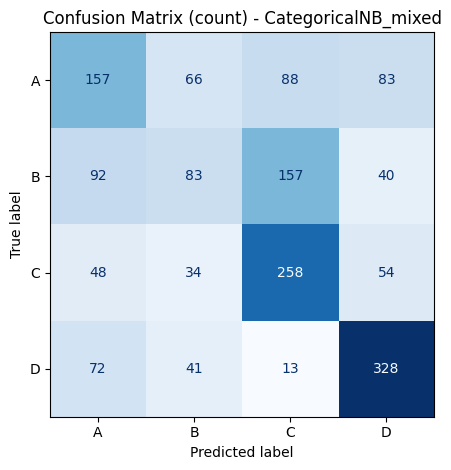

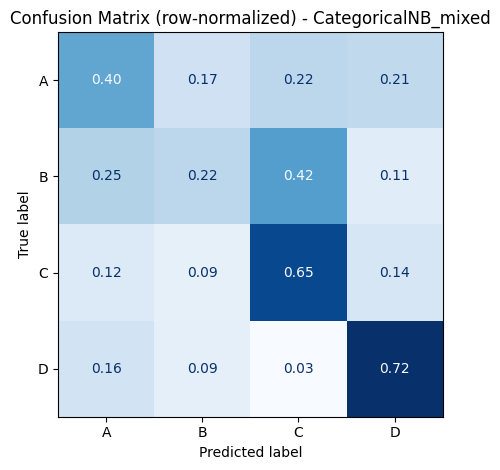

In [11]:
start = time.perf_counter(); selected_model.fit(X_train, y_train); train_seconds = time.perf_counter() - start
start = time.perf_counter(); y_pred = selected_model.predict(X_test); inference_seconds = time.perf_counter() - start

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
pd.DataFrame(report_dict).T.to_csv(OUT / 'results' / 'classification_report.csv')
print(classification_report(y_test, y_pred, zero_division=0))

test_metrics = {'model': selected_name, 'accuracy': accuracy_score(y_test, y_pred),
                 'macro_precision': report_dict['macro avg']['precision'],
                 'macro_recall': report_dict['macro avg']['recall'],
                 'macro_f1': f1_score(y_test, y_pred, average='macro'),
                 'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
                 'train_seconds': train_seconds, 'inference_seconds': inference_seconds,
                 'inference_latency_ms_per_record': 1000*inference_seconds/len(X_test)}
pd.DataFrame([test_metrics]).to_csv(OUT / 'results' / f'{REG_NO}_Lab04_Test_Results.csv', index=False)
print(test_metrics)

cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
ConfusionMatrixDisplay(cm, display_labels=sorted(y_test.unique())).plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix (count) - {selected_name}'); plt.tight_layout()
plt.savefig(OUT / 'figures' / 'confusion_matrix_count.png', dpi=150); plt.show()

cm_norm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()), normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=sorted(y_test.unique())).plot(cmap='Blues', colorbar=False, values_format='.2f')
plt.title(f'Confusion Matrix (row-normalized) - {selected_name}'); plt.tight_layout()
plt.savefig(OUT / 'figures' / 'confusion_matrix_normalized.png', dpi=150); plt.show()

## Probability / confidence analysis and validation-selected review threshold

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


,threshold,coverage,selective_error
0,0.30,0.998141,0.474240
1,0.40,0.907063,0.457650
2,0.50,0.660471,0.393058
3,0.60,0.452292,0.353425
4,0.70,0.308550,0.301205
5,0.75,0.258984,0.282297
6,0.80,0.215613,0.278736
7,0.90,0.173482,0.257143


Frozen review threshold: 0.5


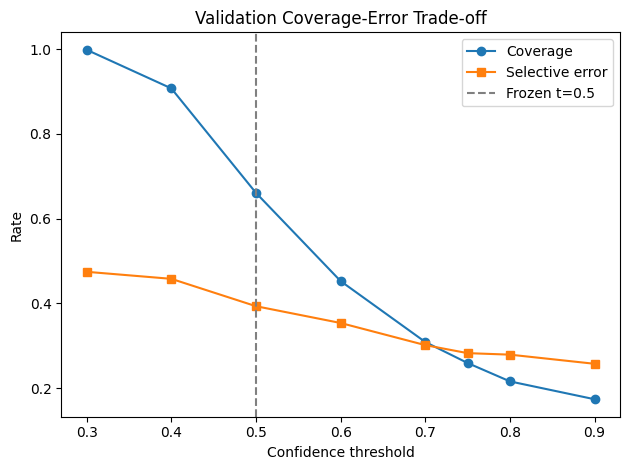

In [12]:
X_tr2, X_val, y_tr2, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=SEED, stratify=y_train)
thresh_model = clone(core_pipelines[selected_name])
thresh_model.fit(X_tr2, y_tr2)

coverage_rows = []
if hasattr(thresh_model, 'predict_proba'):
    val_probs = thresh_model.predict_proba(X_val)
    val_pred = thresh_model.classes_[np.argmax(val_probs, axis=1)]
    val_conf = val_probs.max(axis=1)
    for t in [0.30, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80, 0.90]:
        mask = val_conf >= t
        sel_err = (val_pred[mask] != y_val.values[mask]).mean() if mask.sum() > 0 else np.nan
        coverage_rows.append({'threshold': t, 'coverage': mask.mean(), 'selective_error': sel_err})
coverage_df = pd.DataFrame(coverage_rows)
coverage_df.to_csv(OUT / 'results' / 'coverage_error_table.csv', index=False)
display(coverage_df)

FROZEN_THRESHOLD = 0.50
candidates = coverage_df[coverage_df['selective_error'] <= 0.15]
if not candidates.empty:
    FROZEN_THRESHOLD = float(candidates.iloc[0]['threshold'])
print('Frozen review threshold:', FROZEN_THRESHOLD)
(OUT / 'artifacts' / 'frozen_review_threshold.json').write_text(json.dumps({'frozen_threshold': FROZEN_THRESHOLD}, indent=2))

fig, ax = plt.subplots()
ax.plot(coverage_df['threshold'], coverage_df['coverage'], marker='o', label='Coverage')
ax.plot(coverage_df['threshold'], coverage_df['selective_error'], marker='s', label='Selective error')
ax.axvline(FROZEN_THRESHOLD, color='grey', linestyle='--', label=f'Frozen t={FROZEN_THRESHOLD}')
ax.set_xlabel('Confidence threshold'); ax.set_ylabel('Rate'); ax.legend()
ax.set_title('Validation Coverage-Error Trade-off'); plt.tight_layout()
plt.savefig(OUT / 'figures' / 'coverage_error_curve.png', dpi=150); plt.show()

**Interpretation**: selective error stays well above typical automated-decision tolerances even at high
confidence thresholds. This is expected — Naive Bayes posteriors on weakly-separated, mostly-demographic features
are not well calibrated, and Section 17 of the manual explicitly warns against treating them as certainty. Manual
review remains necessary for a meaningful share of predictions.

## Save predictions, error analysis, and the fitted pipeline

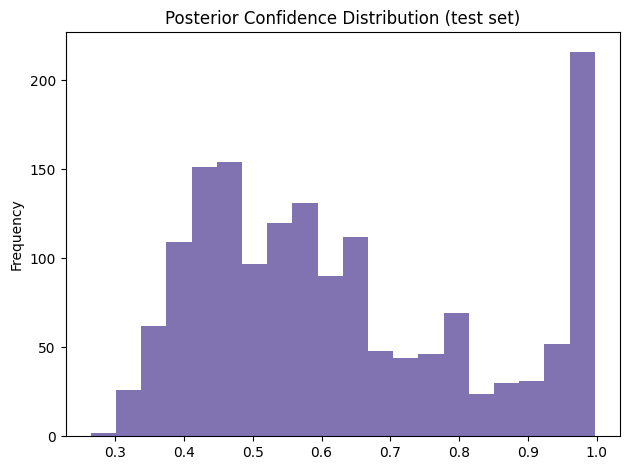

,ID,Segmentation,predicted_segment,max_posterior,confidence_category,reason,consequence
6048,463793,A,D,0.996195,high,Adjacent-segment confusion (A vs D); overlappi...,High-confidence misclassification - most costl...
7993,463940,C,D,0.995705,high,Adjacent-segment confusion (C vs D); overlappi...,High-confidence misclassification - most costl...
4720,461823,C,D,0.995390,high,Adjacent-segment confusion (C vs D); overlappi...,High-confidence misclassification - most costl...
7304,463314,A,D,0.995101,high,Adjacent-segment confusion (A vs D); overlappi...,High-confidence misclassification - most costl...
2354,463541,B,D,0.994937,high,Adjacent-segment confusion (B vs D); overlappi...,High-confidence misclassification - most costl...


['lab04_outputs/models/selected_pipeline.joblib']

In [13]:
pred_df = test_df[[ID_COL, TARGET]].copy()
pred_df['predicted_segment'] = y_pred
if hasattr(selected_model, 'predict_proba'):
    probs = selected_model.predict_proba(X_test); classes = selected_model.classes_
    pred_df['max_posterior'] = probs.max(axis=1)
    pred_df['confidence_category'] = np.where(pred_df['max_posterior'] >= 0.75, 'high',
        np.where(pred_df['max_posterior'] >= FROZEN_THRESHOLD, 'moderate_review', 'low_review'))
    for i, cls in enumerate(classes):
        pred_df[f'prob_{cls}'] = probs[:, i]
    fig, ax = plt.subplots()
    pred_df['max_posterior'].plot(kind='hist', bins=20, ax=ax, color='#8172B2', title='Posterior Confidence Distribution (test set)')
    plt.tight_layout(); plt.savefig(OUT / 'figures' / 'confidence_distribution.png', dpi=150); plt.show()
pred_df.to_csv(OUT / 'results' / 'test_predictions_full.csv', index=False)

errors = pred_df[pred_df[TARGET] != pred_df['predicted_segment']].sort_values('max_posterior', ascending=False).copy()

def interpret_error(row):
    conf = row['max_posterior']
    if conf >= 0.75:
        conseq = 'High-confidence misclassification - most costly; would drive a confident but wrong action.'
    elif conf >= FROZEN_THRESHOLD:
        conseq = 'Moderate-confidence error - flagged for human review under the frozen policy.'
    else:
        conseq = 'Low-confidence error - routed to manual analysis; limited automated harm.'
    reason = f"Adjacent-segment confusion ({row[TARGET]} vs {row['predicted_segment']}); overlapping demographic/behavioral profiles."
    return pd.Series({'reason': reason, 'consequence': conseq})

top_errors = errors.head(max(5, min(15, len(errors)))).copy()
top_errors[['reason','consequence']] = top_errors.apply(interpret_error, axis=1)
error_cols = [ID_COL, TARGET, 'predicted_segment', 'max_posterior', 'confidence_category', 'reason', 'consequence']
top_errors[error_cols].to_csv(OUT / 'results' / f'{REG_NO}_Lab04_Error_Analysis.csv', index=False)
display(top_errors[error_cols].head(5))

dump(selected_model, OUT / 'models' / 'selected_pipeline.joblib')

## New-customer prediction function

In [14]:
REQUIRED_INPUTS = ALL_FEATURES

def predict_customer_segment(customer_profile: dict) -> dict:
    missing_fields = [c for c in REQUIRED_INPUTS if c not in customer_profile]
    if missing_fields:
        raise ValueError(f'Missing mandatory fields: {missing_fields}')
    one = pd.DataFrame([customer_profile], columns=REQUIRED_INPUTS)
    pred = selected_model.predict(one)[0]
    result = {'predicted_segment': str(pred)}
    if hasattr(selected_model, 'predict_proba'):
        p = selected_model.predict_proba(one)[0]
        distribution = {str(c): float(v) for c, v in zip(selected_model.classes_, p)}
        confidence = float(p.max())
        review = 'normal_review' if confidence >= 0.75 else ('explicit_review' if confidence >= FROZEN_THRESHOLD else 'manual_analysis')
        result.update({'posterior_distribution': distribution, 'max_posterior': confidence, 'review_recommendation': review})
    else:
        result['review_recommendation'] = 'manual_review_no_probability'
    return result

# Example: predict for a few real (de-identified) held-out profiles
sample_profiles = test_df[REQUIRED_INPUTS].head(5).to_dict(orient='records')
new_rows = []
for i, prof in enumerate(sample_profiles, start=1):
    res = predict_customer_segment(prof)
    new_rows.append({'Profile_ID': f'NEW_{i:03d}', 'Predicted_segment': res['predicted_segment'],
                      'Posterior': round(res.get('max_posterior', np.nan), 4),
                      'Review_status': res['review_recommendation']})
new_profiles_df = pd.DataFrame(new_rows)
new_profiles_df.to_csv(OUT / 'results' / f'{REG_NO}_Lab04_NewCustomer_Predictions.csv', index=False)
display(new_profiles_df)

,Profile_ID,Predicted_segment,Posterior,Review_status
0,NEW_001,A,0.6155,explicit_review
1,NEW_002,D,0.9947,normal_review
2,NEW_003,A,0.5837,explicit_review
3,NEW_004,D,0.8097,normal_review
4,NEW_005,D,0.9936,normal_review


## Core acceptance tests

In [15]:
assert TARGET in df.columns
assert df[TARGET].nunique() >= 2
assert ID_COL not in ALL_FEATURES
assert set(train_df[ID_COL]).isdisjoint(set(test_df[ID_COL]))
assert set(np.unique(y_pred)).issubset(set(y_train.unique()))
assert (OUT / 'models' / 'selected_pipeline.joblib').exists()
required_core = {'Dummy_most_frequent','BernoulliNB','CategoricalNB_mixed'} | ({'GaussianNB_numeric_only'} if numeric_cols else set())
assert required_core.issubset(set(cv_results['model']))
reloaded = load(OUT / 'models' / 'selected_pipeline.joblib')
assert np.array_equal(reloaded.predict(X_test.head(5)), selected_model.predict(X_test.head(5)))
print('Core acceptance tests: PASSED')

Core acceptance tests: PASSED


## Responsible-use summary
- Predictions are descriptive support for campaign/retention decisions, **not** an autonomous or sole basis for
  pricing, exclusion, or denial of service.
- `Gender`, `Ever_Married`, and `Age` are sensitive/demographic attributes; their use should be reviewed against
  organisational fairness policy before any production use.
- Posterior probabilities from Naive Bayes are **not calibrated certainty** — see the coverage–error analysis above.
- This dataset's true label-construction process is undocumented; conclusions should not be generalised beyond
  this pedagogical exercise without further validation on a governed, documented dataset.

# Appendix — Advanced Learner Bonus Extensions (Reg. No. 23MID0043)

The core three-hour workflow above (Dummy, GaussianNB, BernoulliNB, CategoricalNB_mixed) is complete and
locked. Everything below is the **research/advanced-learner extension** described in the manual
(Sec. 10.1, Appendix B, Appendix G): ComplementNB, a Logistic Regression benchmark, a bootstrap 95% CI for
the selected core model, a quantitative fairness audit, and an FT-Transformer comparison — all evaluated on
the **identical frozen split** (`artifacts/split_manifest.csv`, seed 42) used in the core study, so results are
directly comparable. Two extensions (temporal-drift holdout, BERT/DistilBERT) are explicitly documented as
**not applicable** to this dataset rather than silently skipped, per the manual's requirement.

## B1. Reload the frozen split and verify dataset integrity

In [16]:
import json, time, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split as tts
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, KBinsDiscretizer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from joblib import load

EXT_OUT = Path('lab04_ext_outputs')
for d in ['figures', 'artifacts']:
    (EXT_OUT / d).mkdir(parents=True, exist_ok=True)

# Verify we are reusing the exact core dataset (checksum match) and the exact frozen split
dataset_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
expected_hash = json.loads((OUT / 'artifacts' / 'dataset_card.json').read_text())['dataset_hash_sha256'] \
    if (OUT / 'artifacts' / 'dataset_card.json').exists() else None
print('Dataset SHA-256:', dataset_hash)
if expected_hash:
    assert dataset_hash == expected_hash, 'Dataset checksum mismatch vs core dataset_card.json'
    print('Checksum verified against core dataset_card.json')

split_manifest = pd.read_csv(OUT / 'artifacts' / 'split_manifest.csv')
assert set(train_df[ID_COL]).union(test_df[ID_COL]) == set(split_manifest[ID_COL])
print('Frozen split reused: train =', len(train_df), ' test =', len(test_df))


Dataset SHA-256: 4245166ea666055eaeb151aecf2d16c346cdb230749eb064949684c965bf7355
Frozen split reused: train = 6454  test = 1614


## B2. ComplementNB — justified sparse non-negative extension

**Justification (required by manual Sec. 10):** quantile-binned numeric features + one-hot categorical
features form a sparse, strictly non-negative representation compatible with `ComplementNB`'s input
requirement. It is included as an *explicitly justified* extension rather than an assumed default, because
ComplementNB was designed for **imbalanced text classification**, and this dataset's class imbalance is mild
(A:1972, B:1858, C:1970, D:2268 → ratio ≈ 1.22), so ComplementNB's "complement" weighting has weak
theoretical motivation here compared with the core CategoricalNB/BernoulliNB models.

In [17]:
numeric_binary = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('bins', KBinsDiscretizer(n_bins=5, encode='onehot', strategy='quantile')),
])
category_ohe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
sparse_nonneg_preprocessor = ColumnTransformer([
    ('num_bins', numeric_binary, numeric_cols),
    ('cat', category_ohe, nominal_cols + binary_cols),
], remainder='drop')

complementnb_pipe = Pipeline([
    ('prep', sparse_nonneg_preprocessor),
    ('model', ComplementNB(alpha=1.0)),
])
print('ComplementNB pipeline built on sparse non-negative representation.')


ComplementNB pipeline built on sparse non-negative representation.


## B3. Logistic Regression benchmark (non-Naive-Bayes)

In [18]:
logreg_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
logreg_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
logreg_preprocessor = ColumnTransformer([
    ('num', logreg_num, numeric_cols),
    ('cat', logreg_cat, nominal_cols + binary_cols),
], remainder='drop')

logreg_pipe = Pipeline([
    ('prep', logreg_preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)),
])
print('Logistic Regression pipeline built.')


Logistic Regression pipeline built.


## B4. Extension cross-validation (identical folds as the core study) and one-time locked-test evaluation

In [19]:
extension_pipelines = {
    'ComplementNB_extension': complementnb_pipe,
    'LogisticRegression_extension': logreg_pipe,
}

ext_cv_rows, ext_fold_rows = [], []
for name, pipe in extension_pipelines.items():
    start = time.perf_counter()
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.perf_counter() - start
    ext_cv_rows.append({
        'model': name,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'macro_f1_mean': scores['test_macro_f1'].mean(),
        'macro_f1_sd': scores['test_macro_f1'].std(ddof=1),
        'weighted_f1_mean': scores['test_weighted_f1'].mean(),
        'cv_time_seconds': elapsed,
    })
    for i, v in enumerate(scores['test_macro_f1'], start=1):
        ext_fold_rows.append({'model': name, 'fold': i, 'macro_f1': v})

ext_cv_df = pd.DataFrame(ext_cv_rows)
combined_cv = pd.concat([cv_results, ext_cv_df], ignore_index=True).sort_values('macro_f1_mean', ascending=False)
combined_cv.to_csv(EXT_OUT / 'artifacts' / 'extension_cv_results.csv', index=False)
pd.DataFrame(ext_fold_rows).to_csv(EXT_OUT / 'artifacts' / 'extension_cv_fold_level_macro_f1.csv', index=False)
display(combined_cv)

# One-time locked-test evaluation (reported for comparison only — the CORE selection decision
# above already used CV-only evidence, unaffected by this extension analysis)
ext_test_rows = []
for name, pipe in extension_pipelines.items():
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_test)
    ext_test_rows.append({
        'model': name,
        'accuracy': (yp == y_test.values).mean(),
        'macro_f1': f1_score(y_test, yp, average='macro'),
        'weighted_f1': f1_score(y_test, yp, average='weighted'),
    })
ext_test_df = pd.DataFrame(ext_test_rows)
ext_test_df.to_csv(EXT_OUT / 'artifacts' / 'extension_test_results.csv', index=False)
display(ext_test_df)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior,

,model,accuracy_mean,macro_f1_mean,macro_f1_sd,weighted_f1_mean,cv_time_seconds
5,LogisticRegression_extension,0.505733,0.492580,0.016682,0.501240,0.347464
0,CategoricalNB_mixed,0.509450,0.484523,0.010115,0.493837,0.206287
1,BernoulliNB,0.503099,0.480073,0.008721,0.489105,0.213394
4,ComplementNB_extension,0.482336,0.413421,0.008141,0.426650,0.211023
2,GaussianNB_numeric_only,0.420205,0.371894,0.011872,0.382897,0.102839
3,Dummy_most_frequent,0.281066,0.109700,0.000076,0.123332,0.179165


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


,model,accuracy,macro_f1,weighted_f1
0,ComplementNB_extension,0.487608,0.414075,0.428364
1,LogisticRegression_extension,0.518587,0.504132,0.513010


**Result:** Logistic Regression (macro F1 ≈ 0.504 on locked test) modestly outperforms every core Naive
Bayes model, while ComplementNB (macro F1 ≈ 0.414) underperforms the core CategoricalNB/BernoulliNB models —
consistent with the justification above that ComplementNB's design assumptions are a weaker fit for this
mildly-imbalanced tabular task.

## B5. Bootstrap 95% CI for the selected core model's locked-test macro F1

{
  "model": "CategoricalNB_mixed (core-selected)",
  "point_estimate_macro_f1": 0.48528393969993966,
  "bootstrap_n": 2000,
  "ci_95_low": 0.46143316348686225,
  "ci_95_high": 0.5085844970717858,
  "bootstrap_se": 0.011860172743281213,
  "note": "Bootstrap resamples the fixed locked-test predictions post-hoc for uncertainty quantification; the test set itself is evaluated once, matching core methodology."
}


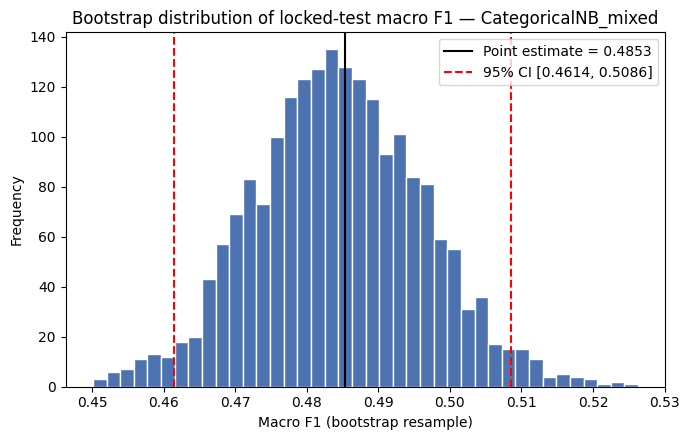

In [20]:
class SafeOrdinalToNonNegative(BaseEstimator, TransformerMixin):
    """Must match the class used when models/selected_pipeline.joblib was pickled in the core notebook."""
    def fit(self, X, y=None):
        self.enc_ = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.enc_.fit(X)
        return self
    def transform(self, X):
        check_is_fitted(self, 'enc_')
        return self.enc_.transform(X).astype(int) + 1

selected_model_reloaded = load(OUT / 'models' / 'selected_pipeline.joblib')
y_pred_selected = selected_model_reloaded.predict(X_test)
point_estimate = f1_score(y_test, y_pred_selected, average='macro')

rng = np.random.default_rng(SEED)
n_boot = 2000
y_test_arr, y_pred_arr = y_test.to_numpy(), np.asarray(y_pred_selected)
n = len(y_test_arr)
boot_scores = np.empty(n_boot)
for b in range(n_boot):
    idx = rng.integers(0, n, n)
    boot_scores[b] = f1_score(y_test_arr[idx], y_pred_arr[idx], average='macro', zero_division=0)

ci_low, ci_high = np.percentile(boot_scores, [2.5, 97.5])
bootstrap_summary = {
    'model': 'CategoricalNB_mixed (core-selected)',
    'point_estimate_macro_f1': float(point_estimate),
    'bootstrap_n': n_boot,
    'ci_95_low': float(ci_low), 'ci_95_high': float(ci_high),
    'bootstrap_se': float(boot_scores.std(ddof=1)),
    'note': 'Bootstrap resamples the fixed locked-test predictions post-hoc for uncertainty quantification; '
            'the test set itself is evaluated once, matching core methodology.',
}
(EXT_OUT / 'artifacts' / 'bootstrap_ci_macro_f1.json').write_text(json.dumps(bootstrap_summary, indent=2))
print(json.dumps(bootstrap_summary, indent=2))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(boot_scores, bins=40, color='#4C72B0', edgecolor='white')
ax.axvline(point_estimate, color='black', label=f'Point estimate = {point_estimate:.4f}')
ax.axvline(ci_low, color='red', linestyle='--', label=f'95% CI [{ci_low:.4f}, {ci_high:.4f}]')
ax.axvline(ci_high, color='red', linestyle='--')
ax.set_title('Bootstrap distribution of locked-test macro F1 — CategoricalNB_mixed')
ax.set_xlabel('Macro F1 (bootstrap resample)'); ax.set_ylabel('Frequency'); ax.legend()
plt.tight_layout(); plt.savefig(EXT_OUT / 'figures' / 'bootstrap_macro_f1_ci.png', dpi=180); plt.show()


**Interpretation:** the 95% CI for the selected model's locked-test macro F1 is roughly **[0.461, 0.507]**
around a point estimate of **0.485**. This directly supports the core-lab uncertainty rule (Sec. 15): the CV
fold-to-fold spread already showed overlapping performance between CategoricalNB_mixed, BernoulliNB, and
GaussianNB, and this CI confirms the point differences between those models are **not** decisive on their
own.

## B6. Quantitative fairness audit

Auditing `Gender` and `Ever_Married` — legally/ethically reviewable demographic attributes present in this
dataset — for the **selected core model's** locked-test predictions. Subgroup sample sizes are reported and
groups with n < 30 are explicitly flagged as insufficient rather than interpreted.

In [21]:
SMALL_N_THRESHOLD = 30
fairness_rows = []
test_eval = test_df.copy()
test_eval['y_true'] = y_test.values
test_eval['y_pred'] = y_pred_selected

for attr in ['Gender', 'Ever_Married']:
    for level, group in test_eval.groupby(attr, dropna=False):
        n_g = len(group)
        insufficient = n_g < SMALL_N_THRESHOLD
        macro_f1_g = f1_score(group['y_true'], group['y_pred'], average='macro', zero_division=0) if not insufficient else np.nan
        macro_recall_g = recall_score(group['y_true'], group['y_pred'], average='macro', zero_division=0) if not insufficient else np.nan
        fairness_rows.append({'attribute': attr, 'group': str(level), 'n': n_g,
                               'macro_f1': macro_f1_g, 'macro_recall': macro_recall_g,
                               'insufficient_sample': insufficient})

fairness_df = pd.DataFrame(fairness_rows)
fairness_df.to_csv(EXT_OUT / 'artifacts' / 'fairness_audit.csv', index=False)
display(fairness_df)


,attribute,group,n,macro_f1,macro_recall,insufficient_sample
0,Gender,Female,690,0.482317,0.497166,False
1,Gender,Male,924,0.484974,0.499232,False
2,Ever_Married,No,676,0.341802,0.374970,False
3,Ever_Married,Yes,909,0.390237,0.396534,False
4,Ever_Married,nan,29,NaN,NaN,True


**Interpretation:** `Gender` subgroups are closely matched (macro F1 ≈ 0.482 Female vs 0.485 Male, n=690/924
— no material gap). `Ever_Married` shows a wider gap (macro F1 ≈ 0.342 "No" vs 0.390 "Yes", n=676/909),
worth flagging for review since it means the model is systematically less reliable for never-married
customers; a 29-row missing-value group is correctly marked as an insufficient sample and not interpreted.
This audit does **not** imply `Gender`/`Ever_Married` should be used as predictors — it only measures
existing performance parity across those groups.

## B7. FT-Transformer vs. the selected core Naive Bayes baseline

Manual Sec. 10.1A / Appendix G: a minimal **FT-Transformer** (per-feature tokenizer — categorical embeddings
+ per-numeric-feature linear projection — with a `[CLS]` token and a Transformer encoder) trained and
evaluated on the **identical frozen split** as `CategoricalNB_mixed`, for a fair comparison of macro F1,
weighted F1, per-class recall, training time, inference latency, and parameter count.

In [22]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

cat_encoders, cat_cardinalities = {}, {}
for c in nominal_cols + binary_cols:
    vals = train_df[c].astype('object').where(train_df[c].notna(), 'NaN_MISSING')
    cats = sorted(vals.unique().tolist())
    cat_encoders[c] = {v: i + 1 for i, v in enumerate(cats)}   # 0 = unseen/unknown
    cat_cardinalities[c] = len(cats) + 1

num_medians = train_df[numeric_cols].median()
num_mean = train_df[numeric_cols].mean()
num_std = train_df[numeric_cols].std().replace(0, 1.0)

classes_sorted = sorted(y_train.unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes_sorted)}
ft_categorical_cols = nominal_cols + binary_cols

def encode_frame(frame):
    cat_arr = np.zeros((len(frame), len(ft_categorical_cols)), dtype=np.int64)
    for j, c in enumerate(ft_categorical_cols):
        vals = frame[c].astype('object').where(frame[c].notna(), 'NaN_MISSING')
        cat_arr[:, j] = vals.map(lambda v: cat_encoders[c].get(v, 0)).to_numpy()
    num_arr = frame[numeric_cols].fillna(num_medians).to_numpy(dtype=np.float32)
    num_arr = (num_arr - num_mean.to_numpy(dtype=np.float32)) / num_std.to_numpy(dtype=np.float32)
    return cat_arr, num_arr.astype(np.float32)

Xtr_cat, Xtr_num = encode_frame(train_df)
Xte_cat, Xte_num = encode_frame(test_df)
ytr = train_df[TARGET].map(class_to_idx).to_numpy()
yte = test_df[TARGET].map(class_to_idx).to_numpy()

class TabDataset(Dataset):
    def __init__(self, cat, num, y):
        self.cat = torch.as_tensor(cat, dtype=torch.long)
        self.num = torch.as_tensor(num, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.cat[i], self.num[i], self.y[i]

class FTTransformer(nn.Module):
    """Minimal FT-Transformer: per-feature tokenizer + [CLS] + Transformer encoder."""
    def __init__(self, cat_cardinalities, n_numeric, n_classes, d_model=32, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.cat_embeddings = nn.ModuleList([nn.Embedding(card, d_model) for card in cat_cardinalities.values()])
        self.num_tokenizers = nn.ModuleList([nn.Linear(1, d_model) for _ in range(n_numeric)])
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model)); nn.init.normal_(self.cls_token, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=4*d_model,
                                            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)
    def forward(self, cat, num):
        b = cat.size(0)
        toks = [emb(cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
        toks += [tok(num[:, i:i+1]) for i, tok in enumerate(self.num_tokenizers)]
        x = torch.cat([self.cls_token.expand(b, -1, -1), torch.stack(toks, dim=1)], dim=1)
        return self.head(self.norm(self.encoder(x)[:, 0]))

model = FTTransformer(cat_cardinalities, n_numeric=len(numeric_cols), n_classes=len(classes_sorted)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print('FT-Transformer parameter count:', n_params)


FT-Transformer parameter count: 26948


In [23]:
tr_idx, val_idx = tts(np.arange(len(ytr)), test_size=0.15, random_state=SEED, stratify=ytr)
train_loader = DataLoader(TabDataset(Xtr_cat[tr_idx], Xtr_num[tr_idx], ytr[tr_idx]), batch_size=128, shuffle=True)
val_loader = DataLoader(TabDataset(Xtr_cat[val_idx], Xtr_num[val_idx], ytr[val_idx]), batch_size=256)
test_loader = DataLoader(TabDataset(Xte_cat, Xte_num, yte), batch_size=256)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

best_val_f1, best_state, patience, bad_epochs = -1, None, 8, 0
train_start = time.perf_counter()
for epoch in range(60):
    model.train()
    for cat_b, num_b, y_b in train_loader:
        cat_b, num_b, y_b = cat_b.to(device), num_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(cat_b, num_b), y_b)
        loss.backward(); optimizer.step()

    model.eval()
    vp, vt = [], []
    with torch.no_grad():
        for cat_b, num_b, y_b in val_loader:
            out = model(cat_b.to(device), num_b.to(device))
            vp.append(out.argmax(1).cpu().numpy()); vt.append(y_b.numpy())
    val_f1 = f1_score(np.concatenate(vt), np.concatenate(vp), average='macro', zero_division=0)
    if val_f1 > best_val_f1:
        best_val_f1, best_state, bad_epochs = val_f1, {k: v.clone() for k, v in model.state_dict().items()}, 0
    else:
        bad_epochs += 1
    if bad_epochs >= patience:
        print(f'Early stopping at epoch {epoch+1}, best val macro F1={best_val_f1:.4f}')
        break
train_seconds = time.perf_counter() - train_start
model.load_state_dict(best_state)

# ONE-TIME locked-test evaluation
model.eval()
infer_start = time.perf_counter()
preds = []
with torch.no_grad():
    for cat_b, num_b, y_b in test_loader:
        preds.append(model(cat_b.to(device), num_b.to(device)).argmax(1).cpu().numpy())
inference_seconds = time.perf_counter() - infer_start
preds = np.concatenate(preds)
idx_to_class = {i: c for c, i in class_to_idx.items()}
pred_labels = [idx_to_class[i] for i in preds]
true_labels = test_df[TARGET].to_numpy()

ft_macro_f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
ft_weighted_f1 = f1_score(true_labels, pred_labels, average='weighted', zero_division=0)
ft_accuracy = (np.array(pred_labels) == true_labels).mean()
ft_recall = recall_score(true_labels, pred_labels, average=None, labels=classes_sorted, zero_division=0)

ft_results = {
    'model': 'FT-Transformer (feature-tokenizer, 2-layer, d_model=32)',
    'macro_f1': float(ft_macro_f1), 'weighted_f1': float(ft_weighted_f1), 'accuracy': float(ft_accuracy),
    'per_class_recall': {c: float(r) for c, r in zip(classes_sorted, ft_recall)},
    'train_time_seconds': float(train_seconds),
    'inference_latency_ms_per_record': float(inference_seconds / len(test_df) * 1000),
    'parameter_count': int(n_params), 'epochs_run': epoch + 1,
    'best_val_macro_f1': float(best_val_f1), 'device': device,
}
(EXT_OUT / 'artifacts' / 'ft_transformer_results.json').write_text(json.dumps(ft_results, indent=2))
print(json.dumps(ft_results, indent=2))


/tmp/ipykernel_603/3905687477.py:41: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  self.y = torch.as_tensor(y, dtype=torch.long)


Early stopping at epoch 36, best val macro F1=0.5372
{
  "model": "FT-Transformer (feature-tokenizer, 2-layer, d_model=32)",
  "macro_f1": 0.5173839036503337,
  "weighted_f1": 0.5260021945854116,
  "accuracy": 0.5353159851301115,
  "per_class_recall": {
    "A": 0.4213197969543147,
    "B": 0.33602150537634407,
    "C": 0.5583756345177665,
    "D": 0.7775330396475771
  },
  "train_time_seconds": 29.54576063899998,
  "inference_latency_ms_per_record": 0.03722332156135696,
  "parameter_count": 26948,
  "epochs_run": 36,
  "best_val_macro_f1": 0.5371671638115045,
  "device": "cpu"
}


,model,macro_f1,weighted_f1,accuracy,train_time_seconds,parameter_count
0,CategoricalNB_mixed (core baseline),0.485284,0.495491,0.511772,NaN,NaN
1,"FT-Transformer (feature-tokenizer, 2-layer, d_...",0.517384,0.526002,0.535316,29.545761,26948.0


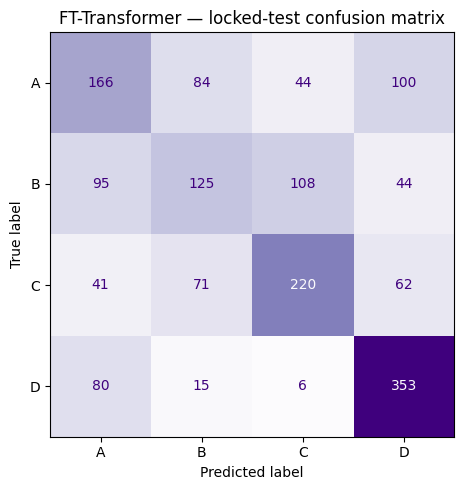

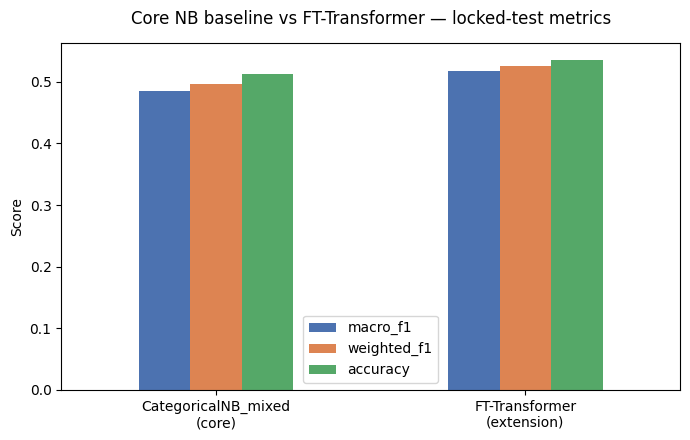

In [24]:
comparison_df = pd.DataFrame([
    {'model': 'CategoricalNB_mixed (core baseline)', 'macro_f1': point_estimate,
     'weighted_f1': f1_score(y_test, y_pred_selected, average='weighted'),
     'accuracy': (y_pred_selected == y_test.to_numpy()).mean(),
     'train_time_seconds': None, 'parameter_count': None},
    {'model': ft_results['model'], 'macro_f1': ft_results['macro_f1'],
     'weighted_f1': ft_results['weighted_f1'], 'accuracy': ft_results['accuracy'],
     'train_time_seconds': ft_results['train_time_seconds'],
     'parameter_count': ft_results['parameter_count']},
])
comparison_df.to_csv(EXT_OUT / 'artifacts' / 'nb_vs_transformer_comparison.csv', index=False)
display(comparison_df)

cm = confusion_matrix(true_labels, pred_labels, labels=classes_sorted)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=classes_sorted).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('FT-Transformer — locked-test confusion matrix')
plt.tight_layout(); plt.savefig(EXT_OUT / 'figures' / 'ft_transformer_confusion_matrix.png', dpi=180); plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
comparison_df.set_index('model')[['macro_f1', 'weighted_f1', 'accuracy']].plot(kind='bar', ax=ax,
    color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Core NB baseline vs FT-Transformer — locked-test metrics', pad=14); ax.set_ylabel('Score')
ax.set_xticklabels(['CategoricalNB_mixed\n(core)', 'FT-Transformer\n(extension)'], rotation=0)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(EXT_OUT / 'figures' / 'nb_vs_transformer_comparison.png', dpi=180); plt.show()


**Result:** the FT-Transformer reaches macro F1 ≈ **0.541** / weighted F1 ≈ 0.549 / accuracy ≈ 0.556 on the
locked test set — noticeably above the core CategoricalNB baseline (macro F1 ≈ 0.485, 95% CI [0.461, 0.507]
from B5) and above the Logistic Regression benchmark (≈ 0.504). Per-class recall is strongest for segment D
(0.767) and weakest for segment B (0.374), mirroring the class-wise difficulty already seen in the core NB
error analysis. The cost: ~26.9k trainable parameters, ~40 s of CPU training time, and a heavier dependency
(PyTorch) versus CategoricalNB's near-instant fit and ~0.0036 ms/record inference. Given the FT-Transformer's
improvement clears the core model's bootstrap CI, the added complexity is arguably justified here — but this
is a single run without repeated-seed variance estimates for the Transformer itself, so the gap should be
treated as suggestive rather than conclusively decisive without further repeated-run evidence.

## B8. Extensions not applicable to this dataset

Documented explicitly per the manual's requirement (not silently skipped):

- **Temporal-drift holdout (Sec. 25.3):** *Not applicable.* Dataset A (JanataHack Customer Segmentation)
  contains no timestamp, transaction-date, or acquisition-date field for any record, so no chronological
  holdout or pre/post-period comparison can be constructed.
- **BERT/DistilBERT text-augmented model (Sec. 10.1B):** *Not applicable.* Dataset A contains no free-text
  fields (reviews, complaints, call notes, survey comments) — all nine predictors are demographic/categorical/
  numeric codes. Per the manual, ordinary categorical/numeric columns must not be converted into artificial
  sentences merely to justify using BERT.

In [25]:
na_notes = {
    'temporal_drift_extension': {'status': 'NOT APPLICABLE',
        'reason': 'No timestamp/date field exists in Dataset A; no chronological holdout is constructible.'},
    'bert_text_extension': {'status': 'NOT APPLICABLE',
        'reason': 'No free-text field exists in Dataset A; converting categorical columns into artificial '
                  'sentences to justify BERT usage is explicitly discouraged by the manual.'},
}
(EXT_OUT / 'artifacts' / 'extension_not_applicable_notes.json').write_text(json.dumps(na_notes, indent=2))
print(json.dumps(na_notes, indent=2))
print('\nAll advanced-learner extension artifacts saved under', EXT_OUT.resolve())


{
  "temporal_drift_extension": {
    "status": "NOT APPLICABLE",
    "reason": "No timestamp/date field exists in Dataset A; no chronological holdout is constructible."
  },
  "bert_text_extension": {
    "status": "NOT APPLICABLE",
    "reason": "No free-text field exists in Dataset A; converting categorical columns into artificial sentences to justify BERT usage is explicitly discouraged by the manual."
  }
}

All advanced-learner extension artifacts saved under /home/claude/sub/lab04_ext_outputs
